# 描述性统计

本notebook完成以下任务：

1. 主要变量描述性统计（分全样本、SOE、非SOE三组）
2. 相关系数矩阵
3. 时序趋势图

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取清洗后数据
df = pd.read_csv("data/clean/panel_data.csv")
print(f"数据加载成功: {len(df)} 观测, {df['stkcd'].nunique()} 家公司")
print(f"年份范围: {df['year'].min()} - {df['year'].max()}")

数据加载成功: 34765 观测, 4046 家公司
年份范围: 2011 - 2025


## 2.1 主要变量描述性统计

分全样本、SOE、非SOE三组计算描述性统计量，并进行均值差异t检验。

In [13]:
# 定义分析变量
vars_analysis = ['lev', 'npr', 'size', 'tang', 'growth', 'ndts']

def desc_stats(data, group_name):
    """计算描述性统计量"""
    result = data[vars_analysis].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
    # 重命名索引
    rename_dict = {
        'count': 'N',
        'mean': 'Mean',
        'std': 'SD',
        'min': 'Min',
        '10%': 'P10',
        '25%': 'P25',
        '50%': 'Median',
        '75%': 'P75',
        '90%': 'P90',
        'max': 'Max'
    }
    result = result.rename(index=rename_dict)
    result.index.name = 'Variable'
    return result.T

# 全样本
print("=" * 80)
print("全样本描述性统计")
print("=" * 80)
desc_all = desc_stats(df, '全样本')
print(desc_all.to_string())

# SOE
print("\n" + "=" * 80)
print("国有企业（SOE=1）描述性统计")
print("=" * 80)
desc_soe = desc_stats(df[df['soe'] == 1], 'SOE')
print(desc_soe.to_string())

# 非SOE
print("\n" + "=" * 80)
print("民营企业（SOE=0）描述性统计")
print("=" * 80)
desc_private = desc_stats(df[df['soe'] == 0], '非SOE')
print(desc_private.to_string())

全样本描述性统计
Variable        N       Mean        SD        Min        P10        P25     Median        P75        P90        Max
lev       34765.0   0.405802  0.194982   0.031995   0.148202   0.247899   0.399770   0.551085   0.672311   0.895787
npr       34765.0   0.037208  0.057609  -0.338507  -0.012086   0.013760   0.036765   0.065809   0.098412   0.222742
size      34765.0  22.307192  1.341091  18.280555  20.810412  21.353868  22.079687  23.035201  24.098277  28.790811
tang      34765.0   0.206083  0.152133   0.002340   0.035030   0.087912   0.174859   0.291126   0.423374   0.736372
growth    34765.0   0.141910  0.279227  -0.318401  -0.057987   0.007168   0.079014   0.186961   0.381826   3.555872
ndts      34765.0   0.025058  0.015565   0.000773   0.007768   0.013443   0.022238   0.033651   0.045968   0.091120

国有企业（SOE=1）描述性统计
Variable        N       Mean        SD        Min        P10        P25     Median        P75        P90        Max
lev       12202.0   0.482446  0.192579   0.03

In [14]:
# SOE vs 非SOE 均值差异t检验
print("\n" + "=" * 80)
print("SOE vs 非SOE 均值差异 t 检验")
print("=" * 80)
print(f"{'变量':<8} {'SOE均值':>12} {'非SOE均值':>12} {'差异':>12} {'t统计量':>10} {'显著性':>8}")
print("-" * 80)

ttest_results = []
for var in vars_analysis:
    soe_vals = df[df['soe'] == 1][var].dropna()
    private_vals = df[df['soe'] == 0][var].dropna()
    
    t_stat, p_val = stats.ttest_ind(soe_vals, private_vals)
    diff = soe_vals.mean() - private_vals.mean()
    
    # 显著性标注
    if p_val < 0.01:
        sig = '***'
    elif p_val < 0.05:
        sig = '**'
    elif p_val < 0.1:
        sig = '*'
    else:
        sig = ''
    
    print(f"{var:<8} {soe_vals.mean():>12.4f} {private_vals.mean():>12.4f} {diff:>12.4f} {t_stat:>10.3f} {sig:>8}")
    
    ttest_results.append({
        'Variable': var,
        'SOE_Mean': soe_vals.mean(),
        'Private_Mean': private_vals.mean(),
        'Difference': diff,
        't_stat': t_stat,
        'p_value': p_val,
        'Significance': sig
    })

ttest_df = pd.DataFrame(ttest_results)
ttest_df.to_csv('output/ttest_soe_results.csv', index=False, encoding='utf-8-sig')
print("\nt检验结果已保存至 output/ttest_soe_results.csv")


SOE vs 非SOE 均值差异 t 检验
变量              SOE均值       非SOE均值           差异       t统计量      显著性
--------------------------------------------------------------------------------
lev            0.4824       0.3644       0.1181     56.301      ***
npr            0.0329       0.0396      -0.0067    -10.374      ***


size          23.0489      21.9061       1.1428     83.007      ***
tang           0.2368       0.1895       0.0473     27.974      ***
growth         0.1086       0.1599      -0.0514    -16.430      ***
ndts           0.0262       0.0244       0.0017      9.975      ***

t检验结果已保存至 output/ttest_soe_results.csv


## 2.2 相关系数矩阵

计算主要变量的Pearson相关系数矩阵。

In [15]:
# 计算相关系数矩阵
vars_corr = ['lev', 'npr', 'size', 'tang', 'growth', 'ndts', 'soe']
corr_matrix = df[vars_corr].corr()

# 计算p值矩阵
def corr_pvalue(data, vars_list):
    n = len(vars_list)
    p_matrix = np.zeros((n, n))
    for i, var1 in enumerate(vars_list):
        for j, var2 in enumerate(vars_list):
            if i == j:
                p_matrix[i, j] = 0
            else:
                _, p = stats.pearsonr(data[var1].dropna(), data[var2].dropna())
                p_matrix[i, j] = p
    return p_matrix

p_matrix = corr_pvalue(df, vars_corr)

# 创建相关系数表（带显著性标注）
def sig_marker(r, p):
    if p < 0.01:
        return f"{r:.3f}***"
    elif p < 0.05:
        return f"{r:.3f}**"
    elif p < 0.1:
        return f"{r:.3f}*"
    else:
        return f"{r:.3f}"

print("=" * 80)
print("相关系数矩阵（* p<0.1, ** p<0.05, *** p<0.01）")
print("=" * 80)

# 创建字符串类型的DataFrame用于显示
corr_display = pd.DataFrame(index=corr_matrix.index, columns=corr_matrix.columns, dtype=object)
for i in range(len(vars_corr)):
    for j in range(len(vars_corr)):
        if i == j:
            corr_display.iloc[i, j] = "1.000"
        else:
            corr_display.iloc[i, j] = sig_marker(corr_matrix.iloc[i, j], p_matrix[i, j])

print(corr_display.to_string())

相关系数矩阵（* p<0.1, ** p<0.05, *** p<0.01）
              lev        npr      size       tang     growth       ndts        soe
lev         1.000  -0.323***  0.517***   0.078***   0.027***   0.055***   0.289***
npr     -0.323***      1.000   0.012**  -0.037***   0.254***  -0.127***  -0.056***
size     0.517***    0.012**     1.000   0.114***   0.025***   0.053***   0.407***
tang     0.078***  -0.037***  0.114***      1.000  -0.095***   0.667***   0.148***
growth   0.027***   0.254***  0.025***  -0.095***      1.000  -0.161***  -0.088***
ndts     0.055***  -0.127***  0.053***   0.667***  -0.161***      1.000   0.053***
soe      0.289***  -0.056***  0.407***   0.148***  -0.088***   0.053***      1.000


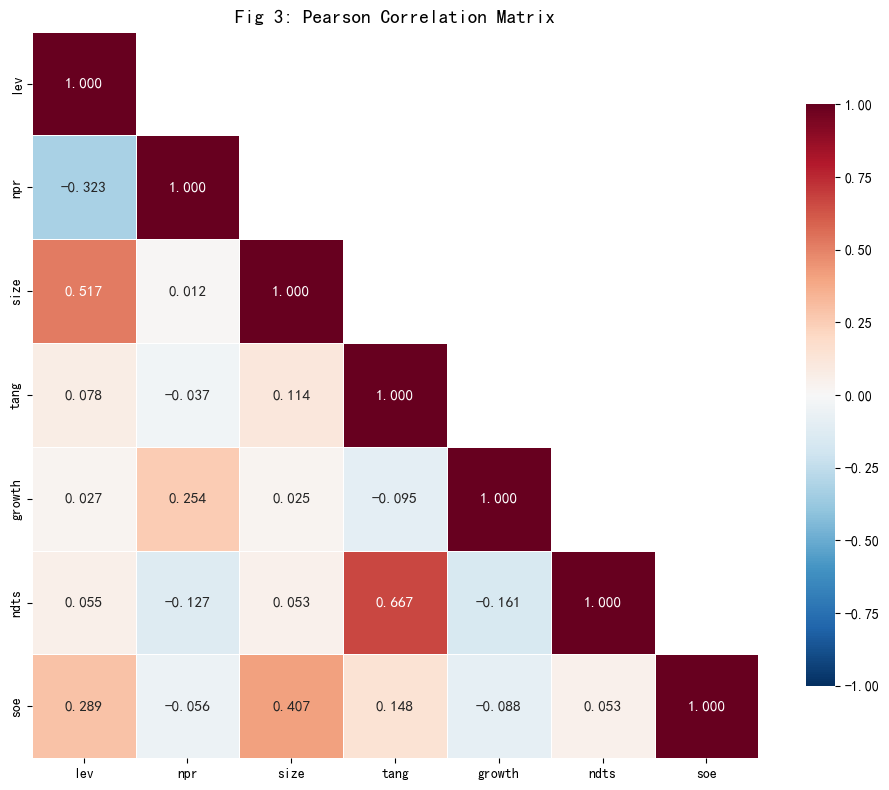

相关系数热力图已保存至 output/figures/Fig3_correlation_heatmap.png


In [16]:
# 绘制热力图
fig, ax = plt.subplots(figsize=(10, 8))

# 上三角mask
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# 绘制热力图
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.3f', 
            cmap='RdBu_r', 
            center=0, 
            vmin=-1, 
            vmax=1, 
            mask=mask,
            square=True, 
            linewidths=0.5,
            cbar_kws={'shrink': 0.8},
            annot_kws={'size': 11})

plt.title('Fig 3: Pearson Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/figures/Fig3_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("相关系数热力图已保存至 output/figures/Fig3_correlation_heatmap.png")

## 2.3 时序趋势图

绘制 Lev 和 NPR 的时序趋势（分 SOE/非SOE），以及 Lev 的分年度箱型图。

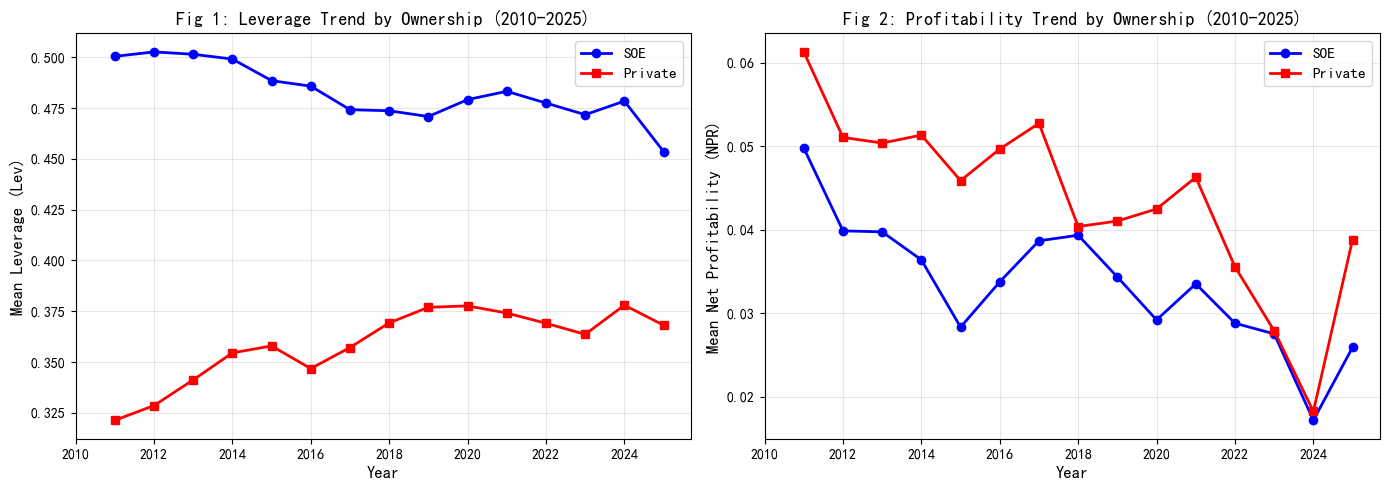

时序趋势图已保存至 output/figures/Fig1_lev_npr_trend.png


In [17]:
# 按年度和SOE分组计算均值
ts_lev = df.groupby(['year', 'soe'])['lev'].mean().unstack()
ts_npr = df.groupby(['year', 'soe'])['npr'].mean().unstack()

# Fig 1 & Fig 2: Lev 和 NPR 时序趋势
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1: Lev时序趋势
axes[0].plot(ts_lev.index, ts_lev[1], 'b-o', label='SOE', linewidth=2, markersize=6)
axes[0].plot(ts_lev.index, ts_lev[0], 'r-s', label='Private', linewidth=2, markersize=6)
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Mean Leverage (Lev)', fontsize=12)
axes[0].set_title('Fig 1: Leverage Trend by Ownership (2010-2025)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(2010, 2026, 2))

# 图2: NPR时序趋势
axes[1].plot(ts_npr.index, ts_npr[1], 'b-o', label='SOE', linewidth=2, markersize=6)
axes[1].plot(ts_npr.index, ts_npr[0], 'r-s', label='Private', linewidth=2, markersize=6)
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Mean Net Profitability (NPR)', fontsize=12)
axes[1].set_title('Fig 2: Profitability Trend by Ownership (2010-2025)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(2010, 2026, 2))

plt.tight_layout()
plt.savefig('output/figures/Fig1_lev_npr_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("时序趋势图已保存至 output/figures/Fig1_lev_npr_trend.png")

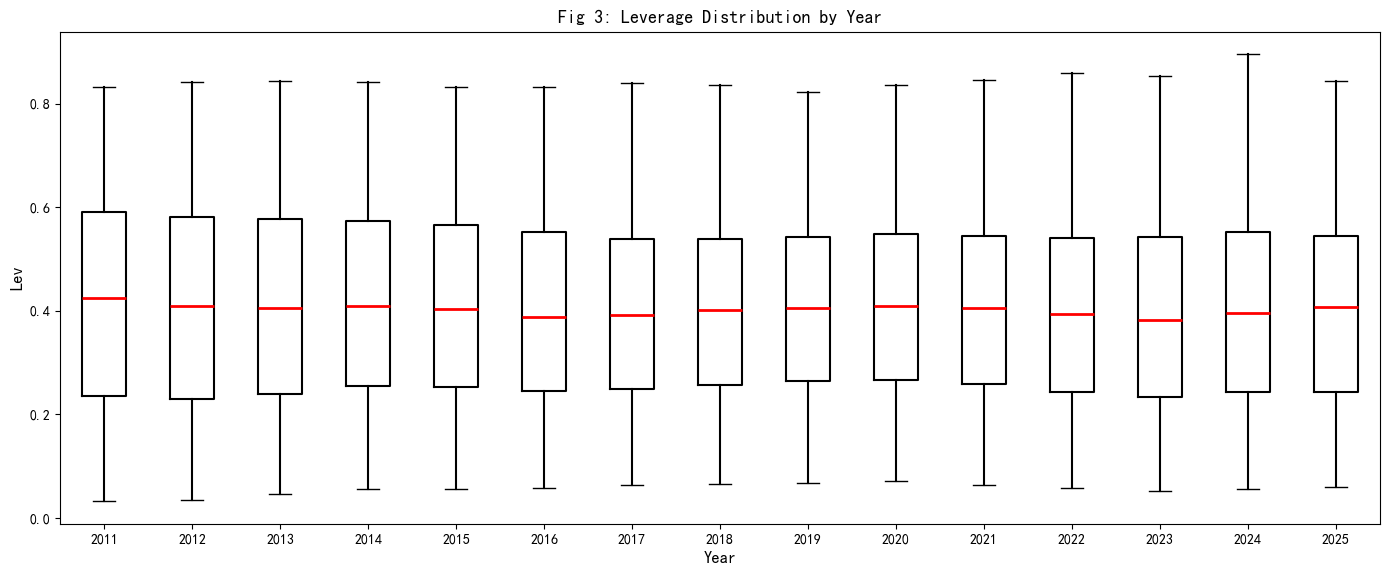

Lev年度箱型图已保存至 output/figures/Fig3_lev_yearly_boxplot.png


In [18]:
# Fig 3: Lev 分年度箱型图
fig, ax = plt.subplots(figsize=(14, 6))

# 按年度分组绘制箱型图
df.boxplot(column='lev', by='year', grid=False, ax=ax,
           boxprops=dict(linewidth=1.5),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(linewidth=1.5),
           flierprops=dict(markersize=3))

ax.set_title('Fig 3: Leverage Distribution by Year', fontsize=13, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Lev', fontsize=12)
plt.suptitle('')  # 去掉默认的suptitle

plt.tight_layout()
plt.savefig('output/figures/Fig3_lev_yearly_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Lev年度箱型图已保存至 output/figures/Fig3_lev_yearly_boxplot.png")

## 2.4 Winsorize前后对比图

绘制Fig 2: Winsorize前后箱型图对比。

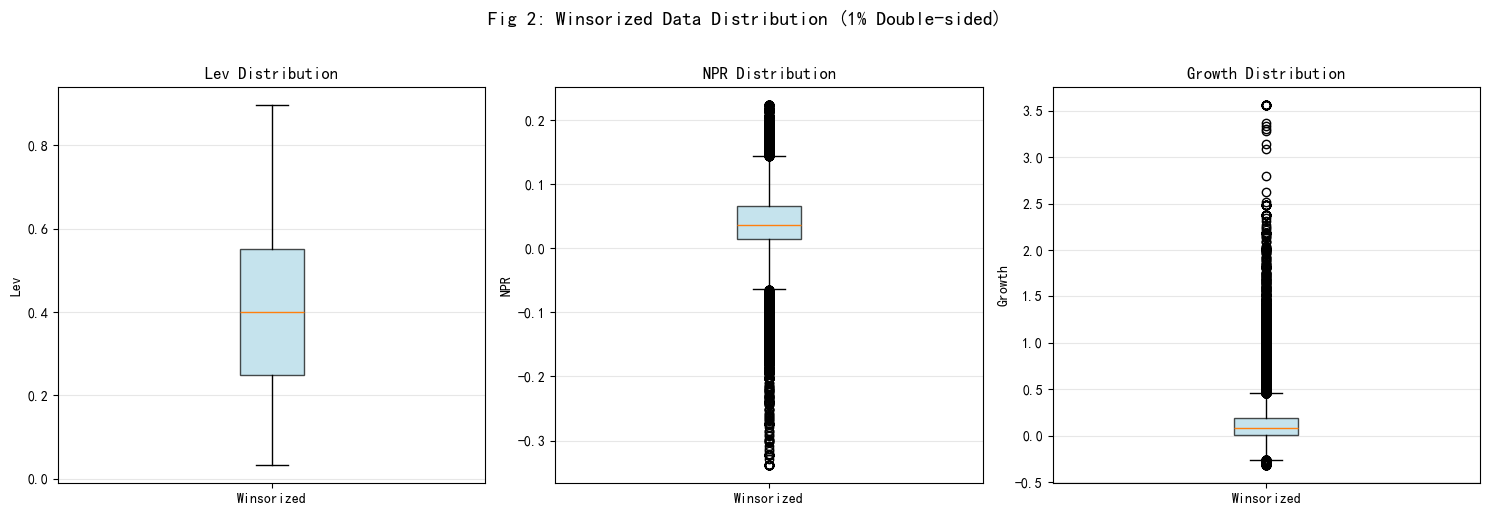

Winsorize分布图已保存至 output/figures/Fig2_winsorize_comparison.png


In [19]:
# 读取原始数据（未Winsorize）用于对比
# 注意：这里需要重新构造原始数据，或在01_data_processing中保存
# 由于原始数据量可能较大，这里展示Winsorize后的分布

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
vars_box = [('lev', 'Lev'), ('npr', 'NPR'), ('growth', 'Growth')]

for i, (var, title) in enumerate(vars_box):
    ax = axes[i]
    data = df[var].dropna()
    
    bp = ax.boxplot([data], labels=['Winsorized'], 
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue', alpha=0.7))
    ax.set_title(f'{title} Distribution', fontsize=12, fontweight='bold')
    ax.set_ylabel(title)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Fig 2: Winsorized Data Distribution (1% Double-sided)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('output/figures/Fig2_winsorize_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("Winsorize分布图已保存至 output/figures/Fig2_winsorize_comparison.png")

In [20]:
# 保存描述性统计结果
desc_all.to_csv('output/desc_stats_all.csv', encoding='utf-8-sig')
desc_soe.to_csv('output/desc_stats_soe.csv', encoding='utf-8-sig')
desc_private.to_csv('output/desc_stats_private.csv', encoding='utf-8-sig')
corr_matrix.to_csv('output/correlation_matrix.csv', encoding='utf-8-sig')

print("=" * 60)
print("描述性统计分析完成！")
print("=" * 60)
print("\n已保存文件：")
print("  - output/desc_stats_all.csv")
print("  - output/desc_stats_soe.csv")
print("  - output/desc_stats_private.csv")
print("  - output/ttest_soe_results.csv")
print("  - output/correlation_matrix.csv")
print("  - output/figures/Fig1_lev_npr_trend.png")
print("  - output/figures/Fig2_winsorize_comparison.png")
print("  - output/figures/Fig3_correlation_heatmap.png")
print("  - output/figures/Fig3_lev_yearly_boxplot.png")

描述性统计分析完成！

已保存文件：
  - output/desc_stats_all.csv
  - output/desc_stats_soe.csv
  - output/desc_stats_private.csv
  - output/ttest_soe_results.csv
  - output/correlation_matrix.csv
  - output/figures/Fig1_lev_npr_trend.png
  - output/figures/Fig2_winsorize_comparison.png
  - output/figures/Fig3_correlation_heatmap.png
  - output/figures/Fig3_lev_yearly_boxplot.png
